# Early fault warning on the IMS bearing dataset: walkthrough

This notebook follows one run-to-failure test (**test2**, the development set) from raw
features to an operator alarm. It runs entirely from the committed feature tables in
`data/features/`, so the 6 GB raw dataset is not needed.

**The question:** a machine runs for days. Nobody labelled anything. Can we warn the
operator *before* a bearing fails, using only what "healthy" looked like?

In [1]:
import sys, yaml
from pathlib import Path
import numpy as np, pandas as pd, matplotlib.pyplot as plt

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT / "src"))
from bearing_efw.dataset import TESTS, fault_frequencies
from bearing_efw.preprocess import load_features, prepare
from bearing_efw.models import Mahalanobis
from bearing_efw.alarm import fit_threshold, k_of_n, first_persistent_alarm
from bearing_efw import plots

cfg = yaml.safe_load((ROOT / "configs/default.yaml").read_text())
TEST = "test2"
df = load_features(ROOT / "data/features", TEST)
print(df.shape); df.head()

(3928, 21)


,timestamp,bearing,channel,rms,peak,p2p,kurtosis,skewness,crest,shape,...,band_0_1k,band_1_2k,band_2_4k,band_4_6k,band_6_8k,band_8_10k,spectral_centroid,env_bpfo,env_bpfi,env_bsf
0,2004-02-12 10:32:39,1,0,0.073475,0.464196,0.840,3.62876,0.083993,6.31775,1.27364,...,0.122722,0.272722,0.223822,0.285771,0.064744,0.030218,3141.31,0.021862,0.015180,0.020443
1,2004-02-12 10:42:39,1,0,0.075338,0.385415,0.757,3.64829,0.052142,5.11580,1.27763,...,0.134546,0.248029,0.224348,0.288005,0.071547,0.033521,3205.67,0.022982,0.015431,0.018839
2,2004-02-12 10:52:39,1,0,0.076189,0.505484,0.903,3.51348,0.032808,6.63458,1.26540,...,0.124197,0.262164,0.225929,0.295698,0.058498,0.033506,3166.37,0.019924,0.014770,0.014843
3,2004-02-12 11:02:39,1,0,0.078691,0.610277,1.184,4.15795,0.041486,7.75538,1.28149,...,0.118327,0.243658,0.232202,0.320604,0.052072,0.033132,3239.73,0.022755,0.016112,0.014831
4,2004-02-12 11:12:39,1,0,0.078437,0.393404,0.782,3.60318,0.028224,5.01551,1.27891,...,0.123513,0.260612,0.225063,0.302552,0.058423,0.029835,3155.15,0.023006,0.015524,0.022475


## 1. What a snapshot becomes

Every 10 minutes the rig records a 1-second, 20 kHz vibration snapshot per bearing. Each
snapshot is reduced to 18 condition indicators: time-domain statistics (RMS, kurtosis,
crest factor...), relative energy in six frequency bands, and **envelope-spectrum energy
at the bearing defect frequencies**. A localized defect produces an impact every time a
roller passes it; the envelope spectrum shows those impacts as a peak at that rate.

In [2]:
{k: round(float(v), 1) for k, v in fault_frequencies().items()}  # Hz, at 2000 rpm

{'bpfo': 236.4, 'bpfi': 296.9, 'bsf': 139.9, 'ftf': 14.8}

## 2. The degradation is visible, but only in hindsight

Bearing 1 develops an outer-race defect. Its **BPFO envelope energy** starts climbing around
hour 88, long before the overall vibration level (RMS) becomes dramatic. Shaded areas are
the training (first 25 % of snapshots) and threshold-calibration (next 10 %) periods.

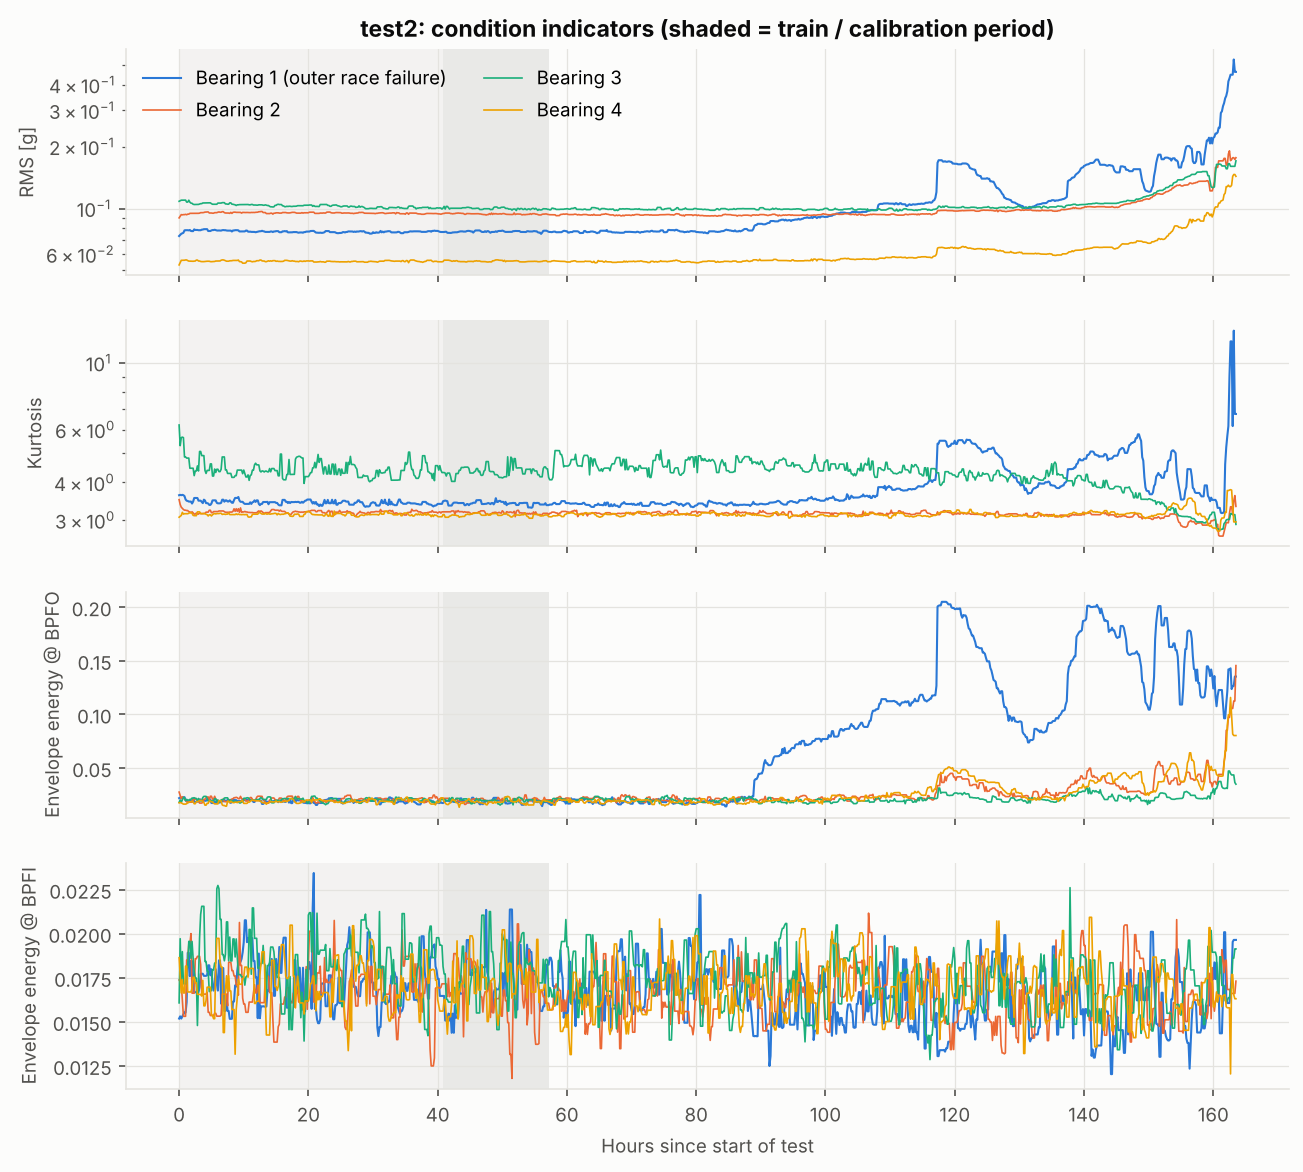

In [3]:
data = prepare(df, cfg["split"]["train_end"], cfg["split"]["calib_end"])
plots.health_indicators(data, TEST, TESTS[TEST], cfg, Path("/tmp/indicators.png"))
from IPython.display import Image; Image("/tmp/indicators.png")

## 3. Learn "healthy", flag "different"

The detector below is the Mahalanobis distance of each snapshot's standardized feature
vector from the healthy training cloud. It never sees a failure. The alarm threshold
comes from the calibration period only, and an alarm needs 4 of the last 6 snapshots
above it, so single noisy spikes do not page anyone.

In [4]:
model = Mahalanobis().fit([d.X[d.train] for d in data.values()])
fig, ax = plt.subplots(figsize=(10, 3.5))
for b, d in data.items():
    score = model.score(d.X)
    thr = fit_threshold(score[d.calib], cfg["threshold"]["quantile"], cfg["threshold"]["margin"])
    alarm = k_of_n(score > thr, cfg["alarm"]["k"], cfg["alarm"]["n"])
    t_alarm = first_persistent_alarm(alarm, d.hours, d.hours[d.calib][-1])
    ax.plot(d.hours, score / thr, color=plots.BEARING_COLORS[b], lw=0.9, label=f"Bearing {b}")
    if t_alarm is not None:
        print(f"Bearing {b}: persistent alarm at {t_alarm:.1f} h -> {d.hours[-1] - t_alarm:.1f} h before end of test")
ax.axhline(1, ls="--", color="gray"); ax.set_yscale("log"); ax.legend(ncol=4)
ax.set_xlabel("Hours since start"); ax.set_ylabel("score / threshold");

Bearing 1: persistent alarm at 89.2 h -> 74.3 h before end of test
Bearing 2: persistent alarm at 135.8 h -> 27.7 h before end of test
Bearing 3: persistent alarm at 144.5 h -> 19.0 h before end of test
Bearing 4: persistent alarm at 117.0 h -> 46.5 h before end of test


Bearing 1 raises a persistent alarm about **74 hours (45 % of the test) before the end**.
The other bearings alarm much later: vibration from the failing bearing travels through
the shaft and housing, which is why the evaluation treats the *first* bearing to alarm and
the dominant defect frequency as the diagnosis.

## 4. All detectors, all tests

`scripts/run_experiment.py` repeats this for four detectors on all three tests. test2 was
used to pick settings; test1 and test3 are held out.

In [5]:
print((ROOT / "reports/results.md").read_text())

| detector         |   test1 B3 lead [h] |   test1 B4 lead [h] |   test2 B1 lead [h] |   test3 B3 lead [h] |   false alarms / 1000 bearing-h | false alarm episodes (t1/t2/t3)   |
|:-----------------|--------------------:|--------------------:|--------------------:|--------------------:|--------------------------------:|:----------------------------------|
| RMS threshold    |                99   |               176.6 |                74.3 |                59.3 |                            5.34 | 15/0/1                            |
| Mahalanobis      |                12.2 |                48   |                74.3 |                58.7 |                            0.67 | 0/0/2                             |
| Isolation Forest |                12.9 |               156.6 |                72.8 |                14   |                            0    | 0/0/0                             |
| LSTM autoencoder |                84.9 |               156.6 |                74.7 |                58.

In [6]:
s = pd.read_csv(ROOT / "reports/summary.csv")
s[s.failed][["test", "bearing", "failure_mode", "detector", "lead_time_h", "diagnosis"]]

,test,bearing,failure_mode,detector,lead_time_h,diagnosis
2,test1,3,inner race defect,RMS threshold,99.05,no clear defect frequency
3,test1,4,roller element defect,RMS threshold,176.62,no clear defect frequency
6,test1,3,inner race defect,Mahalanobis,12.21,no clear defect frequency
7,test1,4,roller element defect,Mahalanobis,47.98,no clear defect frequency
10,test1,3,inner race defect,Isolation Forest,12.87,no clear defect frequency
11,test1,4,roller element defect,Isolation Forest,156.59,no clear defect frequency
14,test1,3,inner race defect,LSTM autoencoder,84.88,no clear defect frequency
15,test1,4,roller element defect,LSTM autoencoder,156.56,no clear defect frequency
16,test2,1,outer race failure,RMS threshold,74.33,outer race (z=6.3)
20,test2,1,outer race failure,Mahalanobis,74.33,outer race (z=6.3)


## Takeaways

* Every detector warns on test2 about three days ahead and correctly points at the **outer race**.
* There is a real trade-off between **lead time and false alarms**: the RMS threshold and the
  LSTM autoencoder warn earliest on test1 but also raise the most nuisance alarms; Isolation
  Forest raised none but warns late on test1 B3 and test3.
* test3 contains a regime shift after a stop at ~360 h that moves every bearing's baseline;
  detectors trained before it see the new normal as anomalous. Handling restarts
  (re-baselining after maintenance) is the main open item for deployment.